In [11]:
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from lsstypes.utils import get_hartlap2007_factor
from clustering_statistics import tools, box_tools


def cov_metrics(cov1, cov2):
    """
    Eqs. (2.17) and (2.18) of arXiv:2404.03007.

    Parameters
    ----------
    cov1 : (N, N) array
        Reference covariance C_R (the matrix to invert).
    cov2 : (N, N) array
        Test covariance C_S.
    assume_a : str, optional
        Passed to scipy.linalg.solve.

    Returns
    -------
    rinv : float
        Eq. (2.17):
            sqrt(tr[(C_R^{-1} C_S - I)^2] / N)
    chi2red : float
        Eq. (2.18):
            tr(C_R^{-1} C_S) / N
    """
    n = cov1.shape[0]
    mat = np.linalg.solve(cov1, cov2)  # C_R^{-1} C_S
    delta = mat - np.eye(n)
    rinv = np.sqrt(np.trace(delta @ delta) / n)
    chi2red = np.trace(mat) / n
    rinv, chi2red = float(np.real_if_close(rinv)), float(np.real_if_close(chi2red))
    print(f"Eq. (2.17): R_inv   = {rinv:.3f}")
    print(f"Eq. (2.18): chi2/N = {chi2red:.3f}")

In [22]:
from scipy.stats import chi2

region = 'NGC'
version = 'glam-uchuu-v2-altmtl'
tracers = [('LRG', (0.4, 0.6)), ('LRG', (0.6, 0.8)), ('LRG', (0.8, 1.1)), ('ELG_LOPnotqso', (1.1, 1.6)), ('QSO', (0.8, 2.1))]
stats_dir = tools.base_stats_dir
all_mocks = {}

def top_n_outliers_mad(x, n):
    x = np.asarray(x)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    score = np.abs(x - med) / (mad + 1e-12)
    idx = np.argsort(score)[-n:]
    return idx

for tracer, zrange in tracers[:1]:
    kw_catalog = dict(imock=150, tracer=tracer, zrange=zrange, version=version, weight='default-FKP', region=region)
    fn = tools.get_stats_fn(kind='covariance_mesh3_spectrum_poles', stats_dir=stats_dir, project='full_shape/analytic_covariance_validation', catalog=kw_catalog)
    covariance_analytic = types.read(fn)#.at.observable.get(observables='spectrum2', tracers=(tools.get_simple_tracer(tracer),) * 2)
    mocks = []
    for imock in range(150, 150 + 400):
        if imock in bad: continue
        fns = [tools.get_stats_fn(kind=kind, stats_dir=stats_dir, project='full_shape/base', basis='sugiyama-diagonal', catalog=kw_catalog | {'imock': imock}) for kind in ['mesh2_spectrum', 'mesh3_spectrum']]
        if fns[0].exists():
            mocks.append(types.ObservableTree([types.read(fn) for fn in fns],
                                              observables=['spectrum2', 'spectrum3'],
                                              tracers=[('LRG',) * 2, ('LRG',) * 3]))
    covariance_mocks = types.cov(mocks)
    
    observable = covariance_analytic.observable
    observabke = observable.at(observables='spectrum2').select(k=slice(0, None, 5)).select(k=(0., 0.3))
    covariance_analytic = covariance_analytic.at.observable.match(observable)
    covariance_mocks = covariance_mocks.at.observable.match(observable)
    #kw = dict(offset=np.arange(2))
    #fig = covariance_analytic.plot_diag(**kw, show=False, color='C0')
    #fig.suptitle(f'{tracer} P+B covariance in {zrange[0]:.1f} < z < {zrange[1]:.1f}', fontsize=12)
    #covariance_mocks.plot_diag(**kw, fig=fig, color='C1', show=True)
    

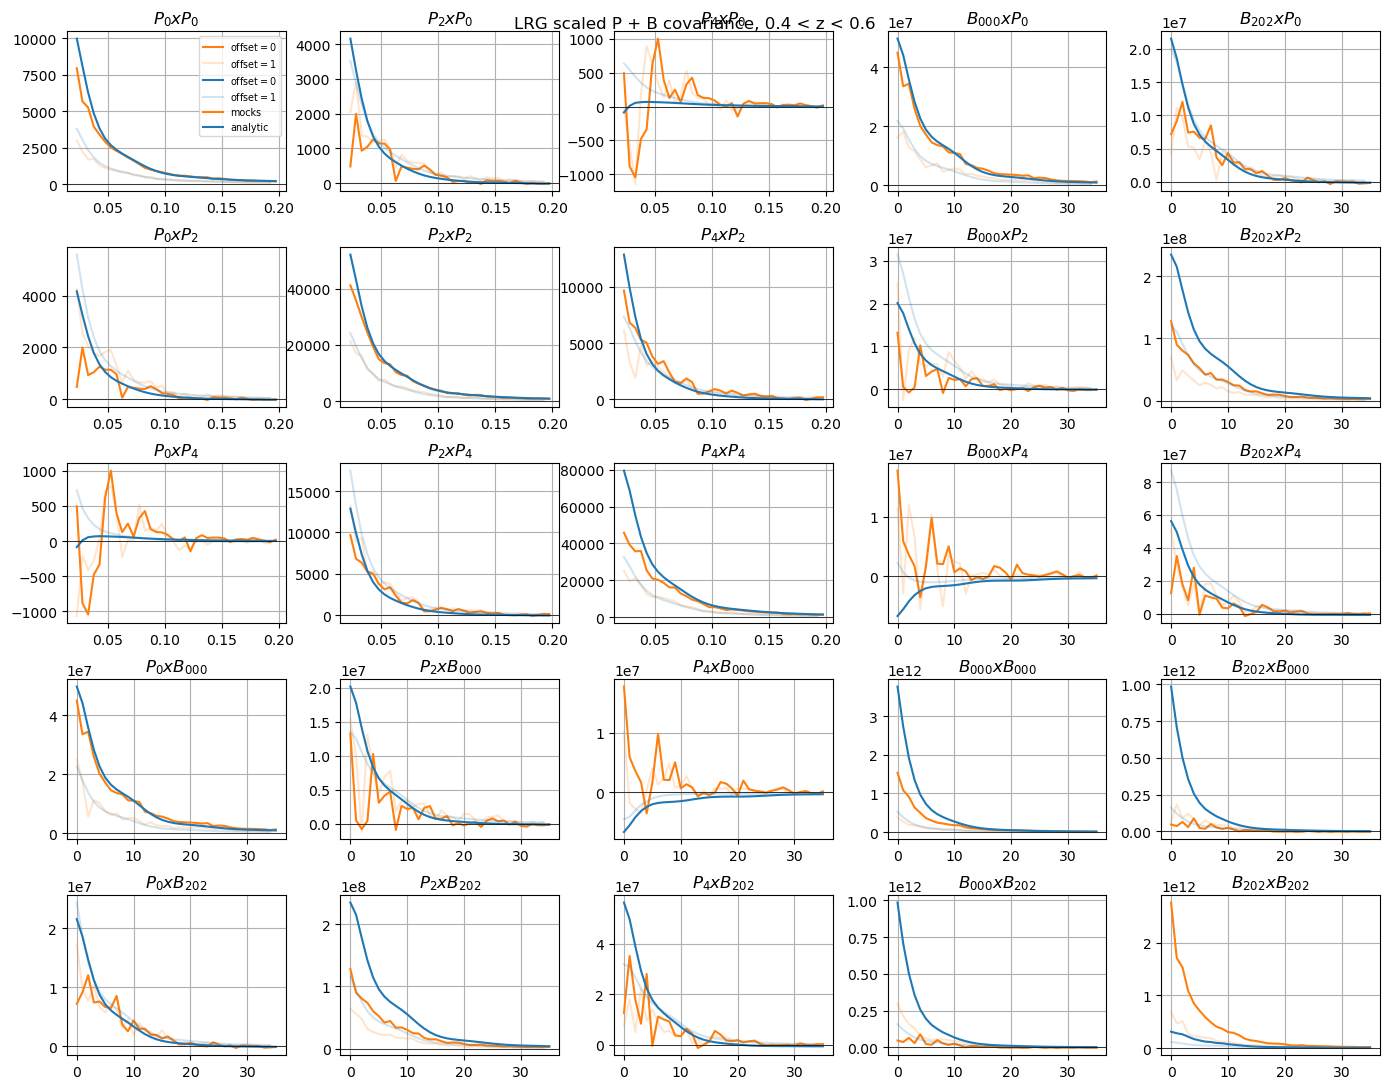

In [28]:
observable = covariance_analytic.observable
observable = observable.at(observables='spectrum2').select(k=(0.02, 0.2))
observable = observable.at(observables='spectrum2').select(k=slice(0, None, 5))  # thin P bins for readability
observable = observable.at(observables='spectrum3').select(k=(0.02, 0.2))
cov_analytic = covariance_analytic.at.observable.match(observable)
cov_mocks = covariance_mocks.at.observable.match(observable)

def pole_name(label):
    ells = label['ells']
    return rf'$P_{ells}$' if np.ndim(ells) == 0 else r'$B_{{{}}}$'.format(''.join(map(str, ells)))

leaves, names, scales = zip(*[(leaf, pole_name(label), leaf.coords('k') if label['observables'] == 'spectrum2' else leaf.coords('k').prod(axis=-1))
                             for label, leaf in observable.items(level=None)])
scale = np.concatenate(scales)
scale = np.outer(scale, scale)
relabeled = types.ObservableTree(list(leaves), poles=list(names))
cov_analytic = cov_analytic.clone(value=np.asarray(cov_analytic.value()) * scale, observable=relabeled)
cov_mocks = cov_mocks.clone(value=np.asarray(cov_mocks.value()) * scale, observable=relabeled)

fig, lax = plt.subplots(len(names), len(names), figsize=(14., 11.))
cov_mocks.plot_diag(offset=[0, 1], color='C1', fig=fig, show=False)
cov_analytic.plot_diag(offset=[0, 1], color='C0', fig=fig, show=False)
for ax in fig.axes:
    ax.axhline(0., color='k', lw=0.5)
fig.axes[0].plot([], [], color='C1', label='mocks')
fig.axes[0].plot([], [], color='C0', label='analytic')
fig.axes[0].legend(fontsize='x-small')
fig.suptitle(f'{tracer} scaled P + B covariance, {zrange[0]:.1f} < z < {zrange[1]:.1f}', fontsize=12)
plt.show()

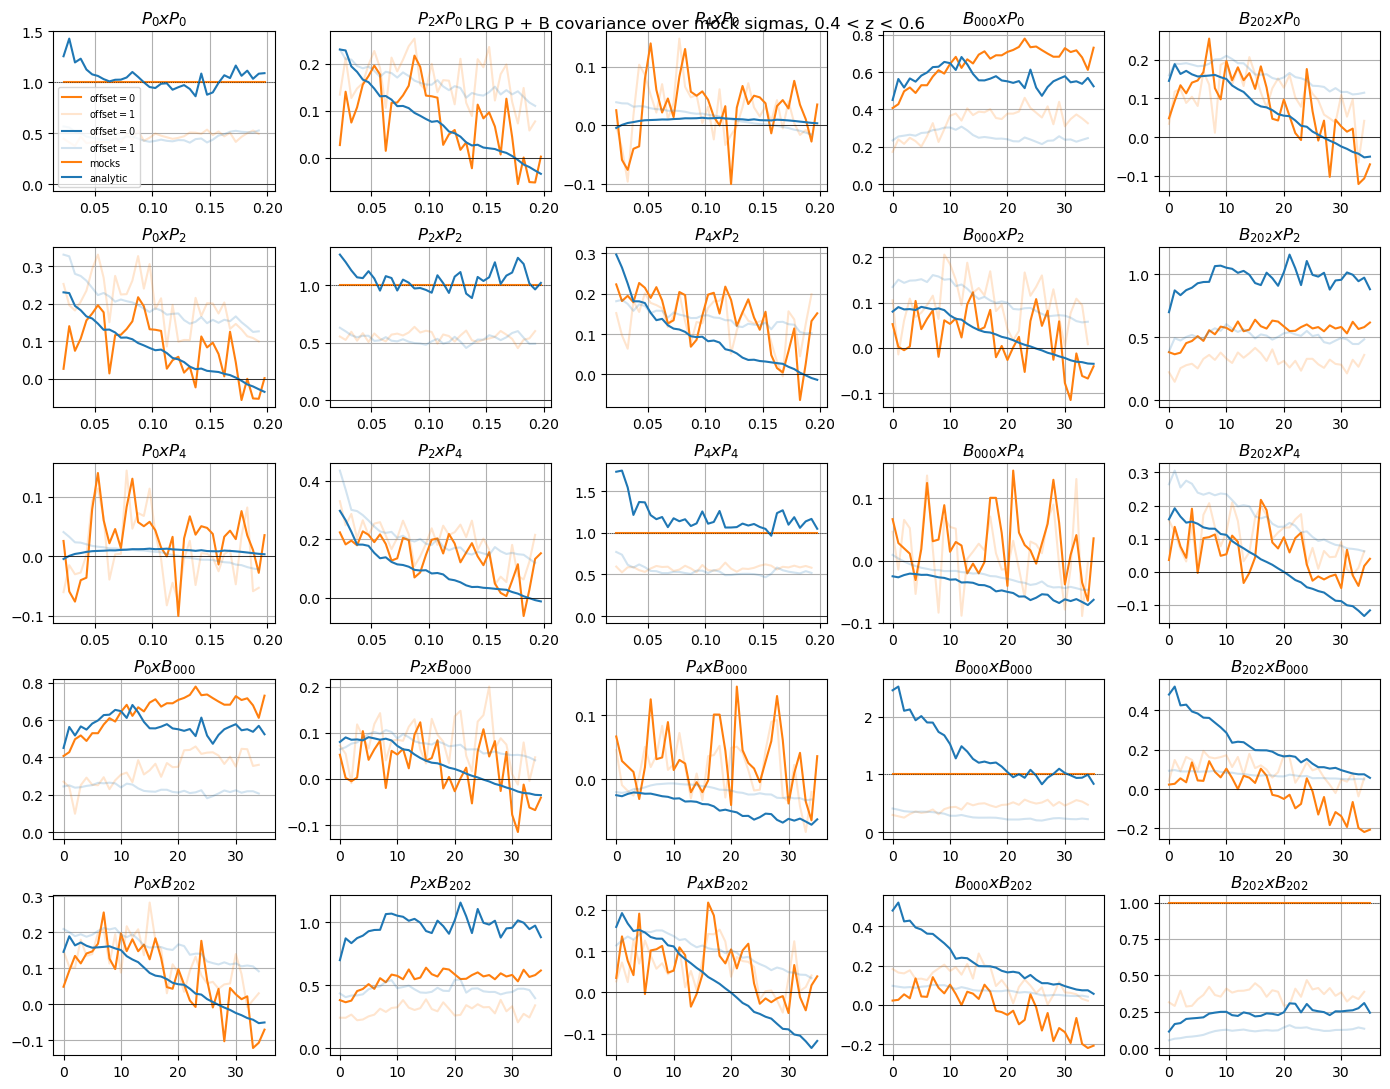

In [23]:
observable = covariance_analytic.observable
observable = observable.at(observables='spectrum2').select(k=(0.02, 0.2))
observable = observable.at(observables='spectrum2').select(k=slice(0, None, 5))  # thin P bins for readability
observable = observable.at(observables='spectrum3').select(k=(0.02, 0.2))
cov_analytic = covariance_analytic.at.observable.match(observable)
cov_mocks = covariance_mocks.at.observable.match(observable)
std_mocks = np.sqrt(np.diag(np.asarray(cov_mocks.value())))
norm = np.outer(std_mocks, std_mocks)

def pole_name(label):
    ells = label['ells']
    return rf'$P_{ells}$' if np.ndim(ells) == 0 else r'$B_{{{}}}$'.format(''.join(map(str, ells)))

leaves, names = zip(*[(leaf, pole_name(label)) for label, leaf in observable.items(level=None)])
relabeled = types.ObservableTree(list(leaves), poles=list(names))
cov_analytic = cov_analytic.clone(value=np.asarray(cov_analytic.value()) / norm, observable=relabeled)
cov_mocks = cov_mocks.clone(value=np.asarray(cov_mocks.value()) / norm, observable=relabeled)

fig, lax = plt.subplots(len(names), len(names), figsize=(14., 11.))
cov_mocks.plot_diag(offset=[0, 1], color='C1', fig=fig, show=False)
cov_analytic.plot_diag(offset=[0, 1], color='C0', fig=fig, show=False)
for iax, ax in enumerate(fig.axes):
    ax.axhline(0., color='k', lw=0.5)
    if iax % (len(names) + 1) == 0:
        ax.axhline(1., color='k', lw=0.5, linestyle=':')
fig.axes[0].plot([], [], color='C1', label='mocks')
fig.axes[0].plot([], [], color='C0', label='analytic')
fig.axes[0].legend(fontsize='x-small')
fig.suptitle(f'{tracer} P + B covariance over mock sigmas, {zrange[0]:.1f} < z < {zrange[1]:.1f}', fontsize=12)
plt.show()

### Holi mocks

In [16]:
from scipy.stats import chi2

region = 'NGC'
version = 'holi-v3-altmtl'
tracers = [('LRG', (0.4, 0.6)), ('LRG', (0.6, 0.8)), ('LRG', (0.8, 1.1)), ('ELG_LOPnotqso', (1.1, 1.6)), ('QSO', (0.8, 2.1))]
stats_dir = tools.base_stats_dir
all_mocks = {}

def top_n_outliers_mad(x, n):
    x = np.asarray(x)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    score = np.abs(x - med) / (mad + 1e-12)
    idx = np.argsort(score)[-n:]
    return idx

bad = [122, 131, 166, 218, 470, 573, 664, 667, 746, 793, 880, 999]
for tracer, zrange in tracers[:1]:
    kw_catalog = dict(imock=0, tracer=tracer, zrange=zrange, version=version, weight='default-FKP', region=region)
    fn = tools.get_stats_fn(kind='covariance_mesh3_spectrum_poles', stats_dir=stats_dir, project='full_shape/analytic_covariance_validation', catalog=kw_catalog)
    covariance_analytic = types.read(fn)#.at.observable.get(observables='spectrum2', tracers=(tools.get_simple_tracer(tracer),) * 2)
    mocks = []
    for imock in range(400):
        if imock in bad: continue
        fns = [tools.get_stats_fn(kind=kind, stats_dir=stats_dir, project='full_shape/base', basis='sugiyama-diagonal', catalog=kw_catalog | {'imock': imock}) for kind in ['mesh2_spectrum', 'mesh3_spectrum']]
        if fns[0].exists():
            mocks.append(types.ObservableTree([types.read(fn) for fn in fns],
                                              observables=['spectrum2', 'spectrum3'],
                                              tracers=[('LRG',) * 2, ('LRG',) * 3]))
    covariance_mocks = types.cov(mocks)
    
    observable = covariance_analytic.observable
    observabke = observable.at(observables='spectrum2').select(k=slice(0, None, 5)).select(k=(0., 0.3))
    covariance_analytic = covariance_analytic.at.observable.match(observable)
    covariance_mocks = covariance_mocks.at.observable.match(observable)
    #kw = dict(offset=np.arange(2))
    #fig = covariance_analytic.plot_diag(**kw, show=False, color='C0')
    #fig.suptitle(f'{tracer} P+B covariance in {zrange[0]:.1f} < z < {zrange[1]:.1f}', fontsize=12)
    #covariance_mocks.plot_diag(**kw, fig=fig, color='C1', show=True)
    

#### Block-by-block diagonal comparison

`plot_diag` over all $(P_\ell, B_\ell)$ block pairs, restricted to the fit range, with both matrices normalized by the **mock** standard deviations so every panel is O(1): in the diagonal panels the offset-0 curve reads directly as the analytic / mock variance ratio (dotted line = 1); the cross panels compare correlation amplitudes in mock-$\sigma$ units.

Caveat: the analytic PB cross blocks currently violate $|\mathrm{corr}| \leq 1$ against their own diagonals (reproduced with a well-behaved theory, so an assembly issue in the windowed cov3 PB terms, under investigation) --- read the cross panels qualitatively.

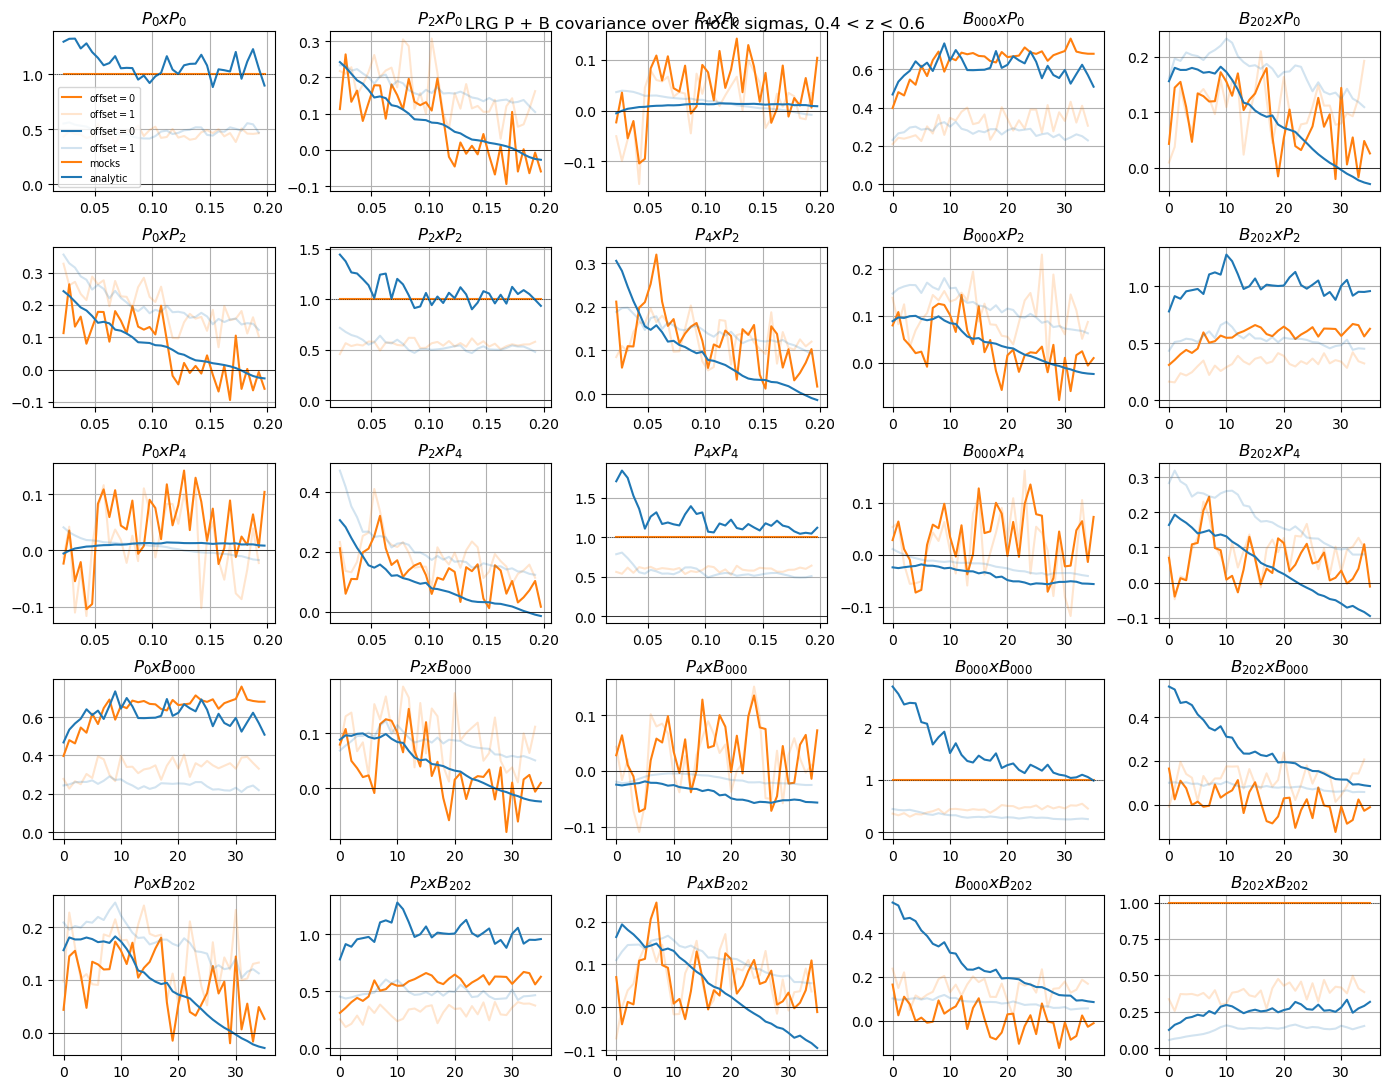

In [17]:
observable = covariance_analytic.observable
observable = observable.at(observables='spectrum2').select(k=(0.02, 0.2))
observable = observable.at(observables='spectrum2').select(k=slice(0, None, 5))  # thin P bins for readability
observable = observable.at(observables='spectrum3').select(k=(0.02, 0.2))
cov_analytic = covariance_analytic.at.observable.match(observable)
cov_mocks = covariance_mocks.at.observable.match(observable)
std_mocks = np.sqrt(np.diag(np.asarray(cov_mocks.value())))
norm = np.outer(std_mocks, std_mocks)

def pole_name(label):
    ells = label['ells']
    return rf'$P_{ells}$' if np.ndim(ells) == 0 else r'$B_{{{}}}$'.format(''.join(map(str, ells)))

leaves, names = zip(*[(leaf, pole_name(label)) for label, leaf in observable.items(level=None)])
relabeled = types.ObservableTree(list(leaves), poles=list(names))
cov_analytic = cov_analytic.clone(value=np.asarray(cov_analytic.value()) / norm, observable=relabeled)
cov_mocks = cov_mocks.clone(value=np.asarray(cov_mocks.value()) / norm, observable=relabeled)

fig, lax = plt.subplots(len(names), len(names), figsize=(14., 11.))
cov_mocks.plot_diag(offset=[0, 1], color='C1', fig=fig, show=False)
cov_analytic.plot_diag(offset=[0, 1], color='C0', fig=fig, show=False)
for iax, ax in enumerate(fig.axes):
    ax.axhline(0., color='k', lw=0.5)
    if iax % (len(names) + 1) == 0:
        ax.axhline(1., color='k', lw=0.5, linestyle=':')
fig.axes[0].plot([], [], color='C1', label='mocks')
fig.axes[0].plot([], [], color='C0', label='analytic')
fig.axes[0].legend(fontsize='x-small')
fig.suptitle(f'{tracer} P + B covariance over mock sigmas, {zrange[0]:.1f} < z < {zrange[1]:.1f}', fontsize=12)
plt.show()

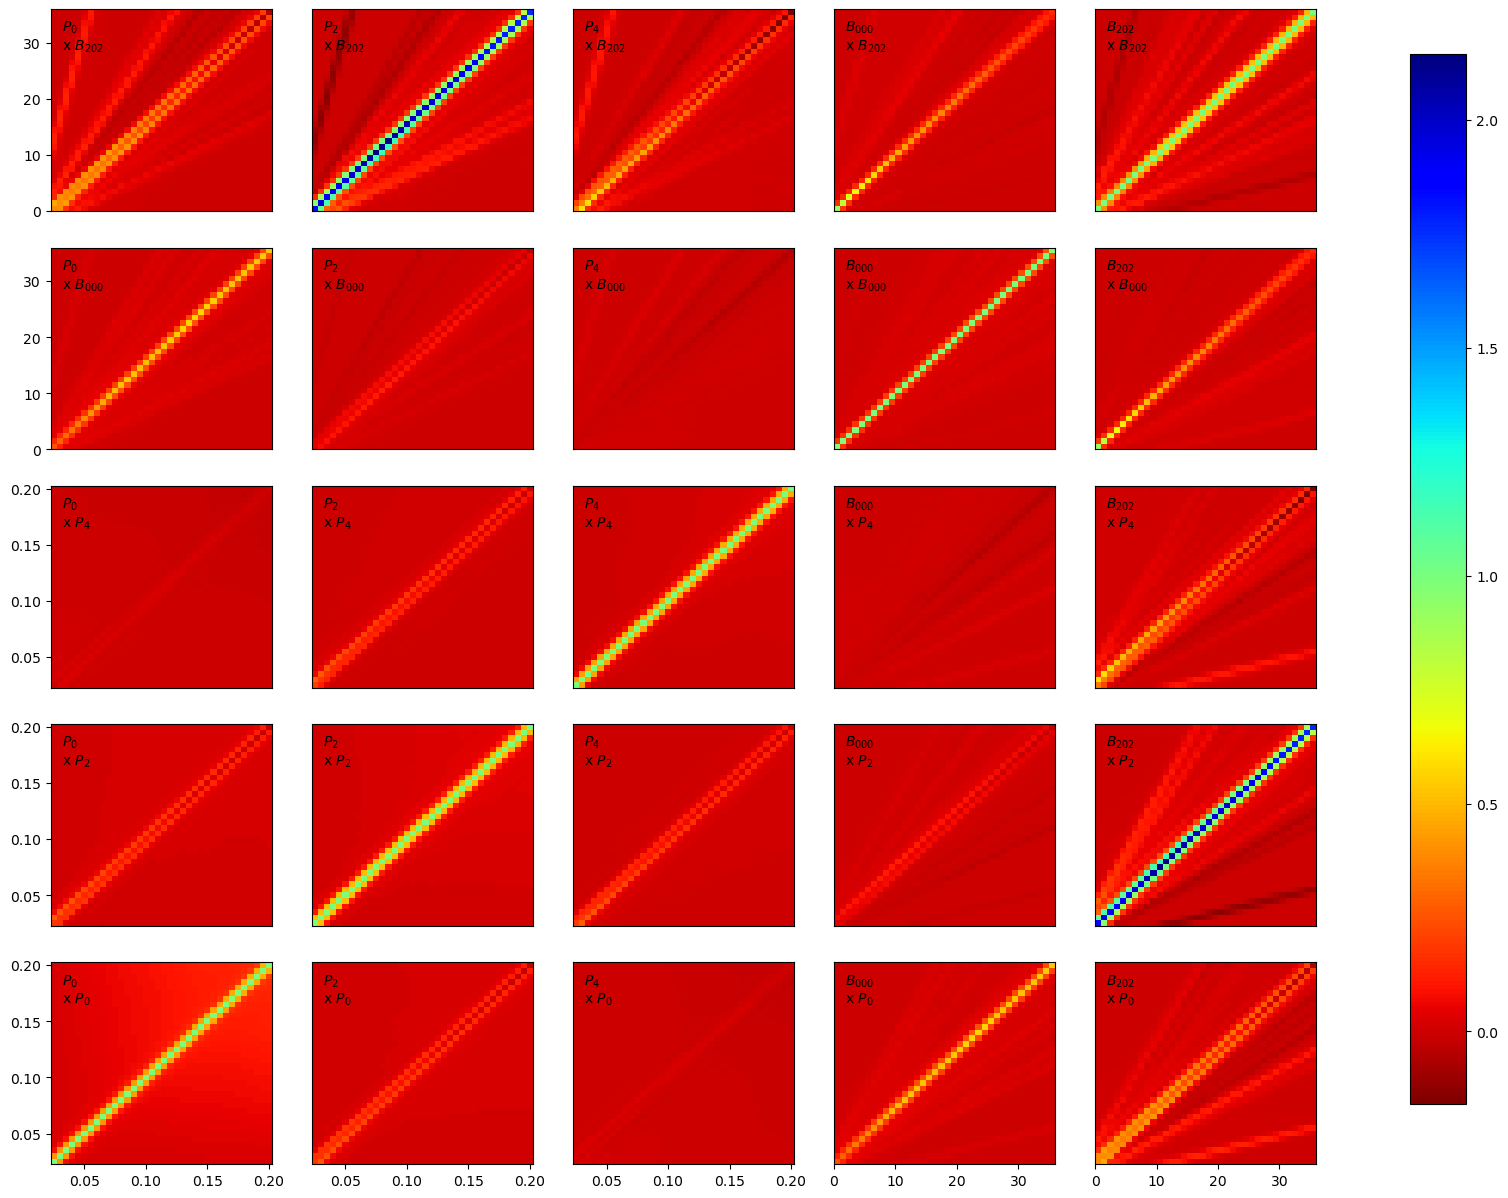

In [18]:
cov_analytic.plot(corrcoef=True, show=True);

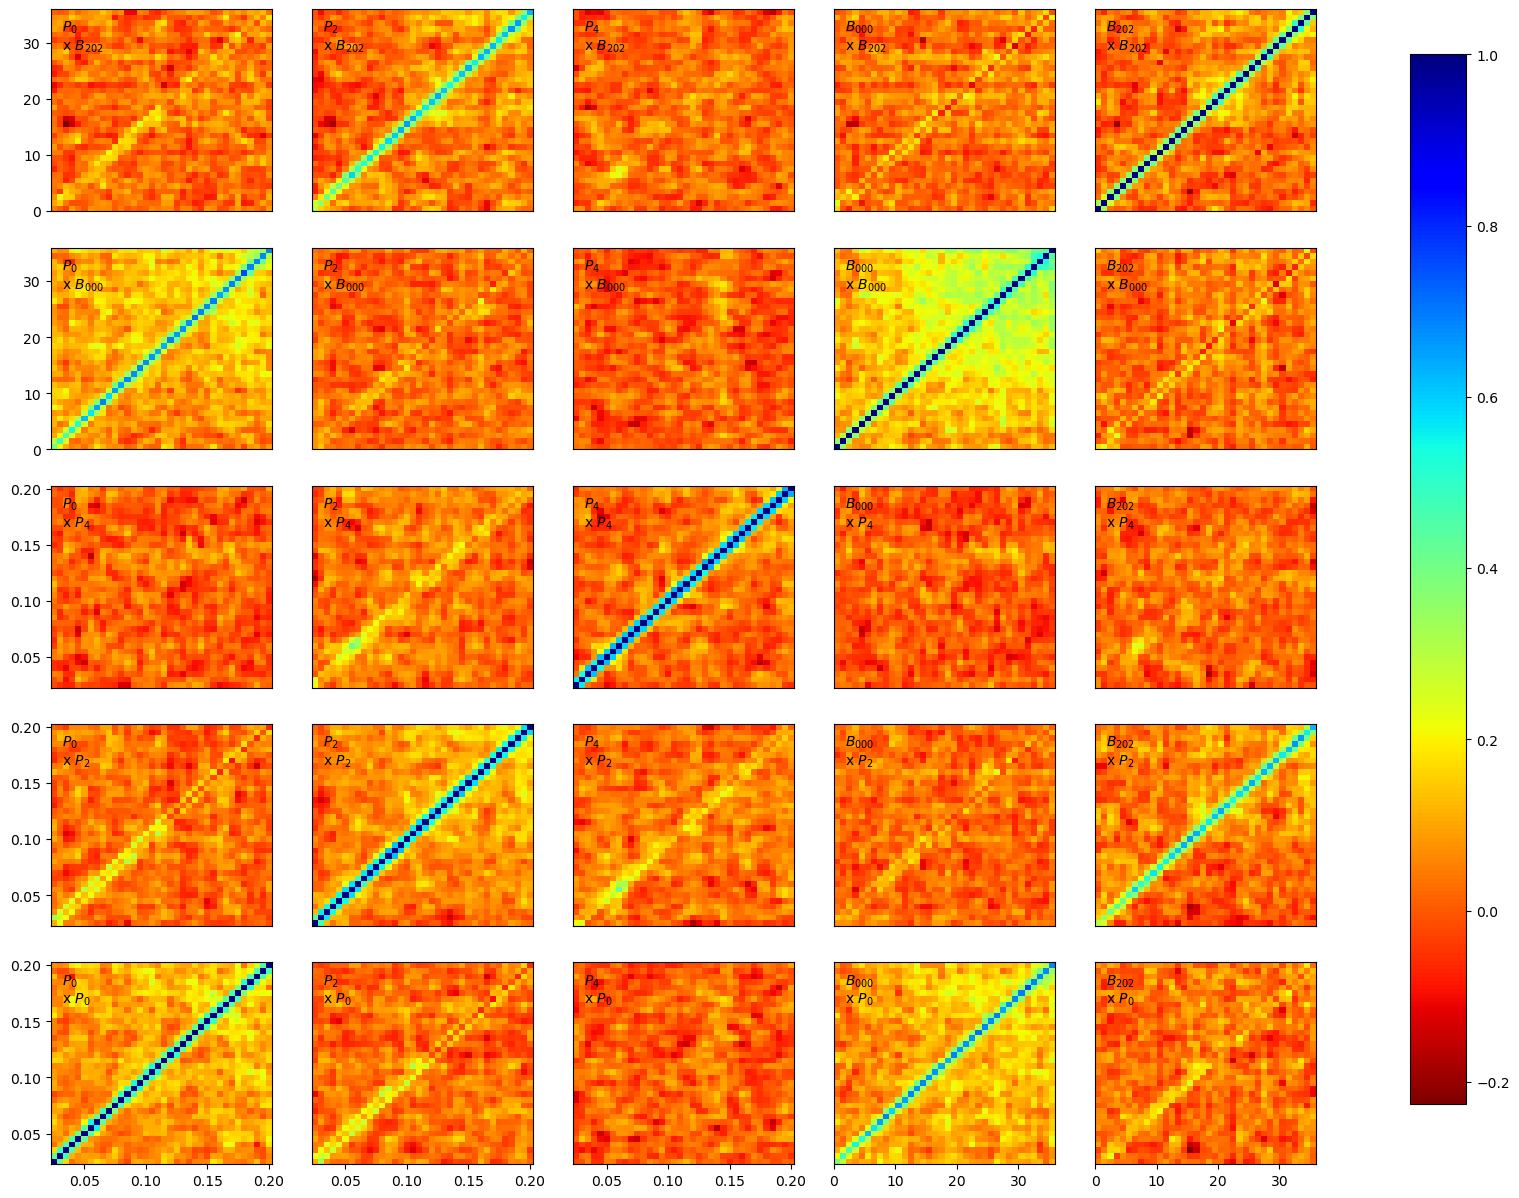

In [19]:
cov_mocks.plot(corrcoef=True, show=True);

In [20]:
covariance_mocks.write('../debug_cov3/covariance_mocks.h5')